<a href="https://colab.research.google.com/github/T-Svitlichna/olist-analytics-DTAA-2026/blob/main/notebook/olist_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
#Part 3 Python: простий прогноз і рекомендації


In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
FILE_IN = "https://raw.githubusercontent.com/T-Svitlichna/olist-analytics-DTAA-2026/refs/heads/main/data/maim_sales_region.csv"


In [2]:
df = pd.read_csv(FILE_IN)

In [3]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115609 entries, 0 to 115608
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          115609 non-null  object 
 1   order_purchase_t  115609 non-null  object 
 2   ym                115609 non-null  object 
 3   customer_state    115609 non-null  object 
 4   Region            115609 non-null  object 
 5   category_EN       115609 non-null  object 
 6   price             115609 non-null  float64
 7   freight_value     115609 non-null  float64
 8   payment_method    115609 non-null  object 
 9   review_score      115609 non-null  int64  
dtypes: float64(2), int64(1), object(7)
memory usage: 8.8+ MB


In [26]:
df.isna().sum()

,0
order_id,0
order_purchase_t,0
ym,0
customer_state,0
Region,0
category_EN,0
price,0
freight_value,0
payment_method,0
review_score,0


In [4]:
df = df.sort_values('ym').reset_index(drop=True) # збити індекси
print('count month', len(df))
df.head()
df = df[(df.ym>= '2017-01')&(df.ym<= '2018-08')].reset_index(drop=True)
print("Month(in prosess)", len(df))
display(df.head(2))
df.tail(2)

count month 115609
Month(in prosess) 115227


,order_id,order_purchase_t,ym,customer_state,Region,category_EN,price,freight_value,payment_method,review_score
0,b4a600b2f7cc0efe40a086465eca8799,2017-01-26 13:32:04,2017-01,SP,Southeast,consoles_games,689.89,20.04,credit_card,5
1,7e61a4c6d93d6ad8a4ca4a8d00094339,2017-01-29 04:52:16,2017-01,SP,Southeast,furniture_decor,59.00,3.60,credit_card,5


,order_id,order_purchase_t,ym,customer_state,Region,category_EN,price,freight_value,payment_method,review_score
115225,b287f7a260f83369913e3203c8b15be0,2018-08-19 19:06:06,2018-08,MG,Southeast,toys,160.00,71.41,credit_card,5
115226,ca207209c40b29d76714f77acf8189e5,2018-08-19 12:03:34,2018-08,SP,Southeast,bed_bath_table,32.99,12.89,credit_card,5


In [15]:
pivot = df.pivot_table(index='ym',
                       values='price',
                       aggfunc='sum')
pivot.head()

,price
ym,
2017-01,126886.42
2017-02,250397.08
2017-03,384903.09
2017-04,379740.52
2017-05,532821.80


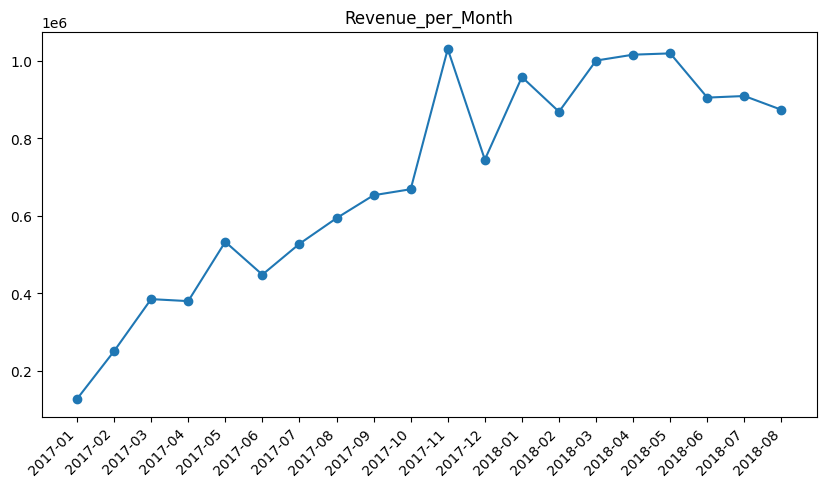

In [19]:
plt.figure(figsize=(10,5))
plt.plot(pivot.index, pivot.price, marker='o')
plt.xticks(rotation=45, ha='right' )
plt.title('Revenue_per_Month')
plt.show()

In [20]:
df_new = {'t': list(range(len(pivot))),
          'ym': list(pivot.index),
          'revenue': list(pivot.price)}
df_new = pd.DataFrame(df_new)
df_new.head()

,t,ym,revenue
0,0,2017-01,126886.42
1,1,2017-02,250397.08
2,2,2017-03,384903.09
3,3,2017-04,379740.52
4,4,2017-05,532821.80


In [46]:

RANDOM_STATE = 42
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error as mean_abssolute_error
X = df_new[['t']]
y = df_new['revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
next_index = len(df_new)
forecast = model.predict(pd.DataFrame({'t': [next_index]}))[0]
print(f"{forecast:,.0f}")
print(f"{model.coef_[0]:,.0f}")
print(f"{model.intercept_:,.0f}")

r2_score(y_test, model.predict(X_test))
print(f"{mean_squared_error(y_test, model.predict(X_test)):,.0f}")
print(f"{mean_abssolute_error(y_test, model.predict(X_test)):,.1f}")
print(f"{r2_score(y_test, model.predict(X_test)):,.3f}")
#print(f"Predict revenue for next month: R${forecast:,.0f} +- {mean_absolute_error(y_test, y_pred):,.0f}")

1,109,657
37,785
353,960
22,231,534,558
138,708.9
0.854


In [44]:
df_new["month"] = df_new['ym'].str[-2:]
season = df_new.groupby('month')["revenue"].mean().rount(0) # фигня не показово

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
X = df_new[['t']]
y = df_new['revenue']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)
model = LinearRegression().fit(X_train, y_train)
next_index = len(df_new)
y_pred = model.predict(X_test)
forecast = model.predict(pd.DataFrame({
    't': [next_index]
}))[0]
print(f"Predict revenue for next month: R${forecast:,.0f}")
print(f"Average growth for month: R${model.coef_[0]:,.0f}")
print("-" * 15)
print(f"MAE: R${mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE: R${np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"Predict accuracy (R2): {r2_score(y_test, y_pred):.1%}")
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
X = df_new[['t']]
y = df_new['revenue']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)
model = LinearRegression().fit(X_train, y_train)
next_index = len(df_new)
y_pred = model.predict(X_test)
forecast = model.predict(pd.DataFrame({
    't': [next_index]
}))[0]
print(f"Predict revenue for next month: R${forecast:,.0f}")
print(f"Average growth for month: R${model.coef_[0]:,.0f}")
print("-" * 15)
print(f"MAE: R${mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE: R${np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"Predict accuracy (R2): {r2_score(y_test, y_pred):.1%}")

Predict revenue for next month: R$1,109,657
Average growth for month: R$37,785
---------------
MAE: R$138,709
RMSE: R$149,102
Predict accuracy (R2): 85.4%
Predict revenue for next month: R$1,109,657
Average growth for month: R$37,785
---------------
MAE: R$138,709
RMSE: R$149,102
Predict accuracy (R2): 85.4%


df_new = {'t': list}